# 1.1. Práctica: Implementar un sistema basado en reglas simples usando Python.

## Introducción de la actividad.

Los sistemas basados en reglas (o sistemas de producción) son una de las formas más tempranas de razonamiento en inteligencia artificial simbólica: representan el conocimiento de un experto como un conjunto de reglas condición-acción y lo aplican sobre un conjunto de hechos para llegar a una conclusión, de forma transparente y verificable paso a paso.

## Propósito de la actividad.

Diseñar, implementar y probar un sistema basado en reglas simples aplicado a un área de interés propio, separando explícitamente los hechos, la base de conocimiento y el motor de inferencia.

## Instrucciones.

Partiendo de las nociones teóricas y prácticas vistas en la unidad, el alumno va a diseñar y desarrollar un sistema basado en reglas simples en código Python o R aplicado en el área de su interés. Tanto el diseño como el código deben ser entregados describiendo detalladamente cada uno de los procesos involucrados, así como la justificación y pertinencia de su implementación.

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `dataclasses` (stdlib) | Define la estructura `Regla` (condición-acción) de la base de conocimiento |
| `typing` (stdlib) | Anotaciones de tipo para las funciones de condición y acción de cada regla |
| `pandas` | Construcción de la tabla comparativa con los resultados de la batería de prueba |
| `matplotlib` | Gráfica de la distribución de decisiones sobre la batería de prueba |

In [1]:
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

from dataclasses import dataclass
from typing import Callable, Any
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print(f"Python     {sys.version}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {matplotlib.__version__}")

Python     3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
pandas     2.3.3
matplotlib 3.10.7


# Diseño del sistema de reglas

## Área de interés: evaluación de riesgo crediticio

El ejemplo proporcionado diagnostica el estado de salud de un paciente a partir de tres síntomas, encadenados en una sola cadena de `if/elif`. Para esta práctica se aplica la misma idea — un sistema basado en reglas — a un área distinta y de interés propio dentro de la ciencia de datos aplicada a finanzas: la **evaluación de riesgo crediticio de solicitudes de préstamo personal**.

Es un dominio especialmente adecuado para un sistema de reglas porque en la práctica bancaria real las políticas de originación de crédito **ya están escritas como reglas explícitas** (razones deuda/ingreso máximas, rangos de score, antigüedad laboral mínima, historial de mora), no como un modelo estadístico entrenado con datos históricos. Frente a un modelo de aprendizaje automático, un sistema de reglas en este dominio tiene ventajas concretas que justifican su uso:

- **Explicabilidad total:** un regulador o un solicitante rechazado puede preguntar "¿por qué?", y el sistema puede responder citando exactamente qué regla se disparó y con qué datos — algo que un modelo de caja negra no ofrece directamente.
- **Auditabilidad:** las políticas de crédito están sujetas a regulación (p. ej. las reglas de *ability-to-repay* de la CFPB); un sistema de reglas permite verificar el cumplimiento de cada política de forma directa, regla por regla.
- **Mantenibilidad ante cambios de política:** si el banco decide bajar el umbral de score mínimo, basta con modificar una regla, sin reentrenar nada.

## ¿Qué es un sistema basado en reglas?

Un sistema basado en reglas (o *sistema de producción*) es una de las formas más antiguas de razonamiento en inteligencia artificial simbólica (Russell & Norvig, 2020). Se compone de tres elementos:

1. **Base de hechos** (o memoria de trabajo): el conjunto de datos conocidos en un momento dado — en esta práctica, un diccionario `hechos` con los datos de la solicitud.
2. **Base de conocimiento**: un conjunto de reglas **condición → acción**. Cada regla observa la base de hechos y, si su condición se cumple, añade un nuevo hecho (o modifica uno existente).
3. **Motor de inferencia**: el algoritmo que decide, en cada paso, qué reglas pueden dispararse y en qué orden, hasta que ya no hay más hechos nuevos que derivar (Giarratano & Riley, 2005).

El ejemplo del enunciado implementa los tres elementos **fusionados en una sola función**: los "hechos" son los tres parámetros de entrada, la "base de conocimiento" son las condiciones del `if/elif`, y el "motor de inferencia" es, implícitamente, el propio orden de evaluación de Python. Es una implementación válida para un caso muy pequeño, pero no separa estos tres elementos, por lo que añadir una regla nueva obliga a reescribir la cadena completa de condicionales, y no queda ningún registro de qué regla se aplicó ni por qué.

Esta práctica separa explícitamente los tres elementos: se define una clase `Regla`, una lista de reglas (la base de conocimiento) y una función `motor_inferencia` genérica que **encadena hacia adelante** (*forward chaining*): a partir de los hechos iniciales de la solicitud, va derivando hechos nuevos (categorías de riesgo) hasta llegar a un hecho final, la decisión, sin que el orden en que se declaran las reglas de categorización afecte el resultado — solo importa el orden para las reglas que **compiten** por el mismo hecho, como se explica más abajo.

## Hechos iniciales (datos de la solicitud)

| Hecho | Tipo | Descripción |
|---|---|---|
| `ingreso_mensual` | float | Ingreso mensual neto del solicitante, en pesos |
| `deuda_mensual` | float | Suma de los pagos mensuales de deudas vigentes del solicitante |
| `score_crediticio` | int | Score crediticio del buró (rango 300-850, escala tipo FICO) |
| `antiguedad_laboral_meses` | int | Antigüedad en el empleo actual, en meses |
| `historial_moroso` | bool | Si el solicitante tuvo una mora mayor a 90 días en los últimos 24 meses |
| `monto_solicitado` | float | Monto del préstamo solicitado, en pesos |

## Reglas de categorización (hechos derivados)

Estas reglas no deciden nada por sí solas: derivan **hechos intermedios** a partir de los hechos iniciales, que después usan las reglas de decisión. Los umbrales no son arbitrarios: están tomados de referencias reales del sector crediticio.

| Regla | Condición | Hecho que deriva | Justificación |
|---|---|---|---|
| `calcular_dti` | siempre (una vez) | `dti` = deuda_mensual / ingreso_mensual | *Debt-to-Income*, la métrica estándar de capacidad de pago en originación de crédito |
| `categorizar_dti` | según el valor de `dti` | `dti_categoria` ∈ {bajo, medio, alto} | Umbrales de 36% y 43%: el 43% es el límite usado en la regla de *ability-to-repay / Qualified Mortgage* de la CFPB (2013) para considerar que un solicitante puede pagar la deuda de forma sostenible |
| `categorizar_score` | según `score_crediticio` | `perfil_crediticio` ∈ {excelente, bueno, regular, malo} | Rangos equivalentes a los publicados por Fair Isaac Corporation para el score FICO (s.f.): ≥740 excelente, 670-739 bueno, 580-669 regular, <580 malo |
| `categorizar_antiguedad` | según `antiguedad_laboral_meses` | `estabilidad_laboral` ∈ {baja, media, alta} | <6 meses se considera periodo de prueba (baja estabilidad); ≥24 meses (2 años) es el criterio típico de estabilidad laboral consolidada en políticas de crédito al consumo |
| `evaluar_historial` | según `historial_moroso` | `riesgo_historial` ∈ {bajo, alto} | Un incumplimiento reciente (mora >90 días) es el predictor individual más fuerte de incumplimiento futuro en modelos de riesgo crediticio |

## Reglas de decisión

Estas reglas sí escriben el hecho final, `decision`. Las cuatro compiten por ese mismo hecho, así que el **orden en la lista importa**: es el mecanismo de resolución de conflictos del motor (equivalente a la especificidad de reglas de un sistema experto clásico (Jackson, 1998)) — la primera regla de la lista cuya condición se cumpla es la que gana, y las siguientes ya no se disparan porque `decision` deja de estar disponible.

| Prioridad | Condición | Decisión |
|---|---|---|
| 1 | `riesgo_historial == "alto"` | Rechazado |
| 2 | `perfil_crediticio == "malo"` | Rechazado |
| 3 | `dti_categoria == "alto"` y `estabilidad_laboral == "baja"` | Rechazado |
| 4 | `perfil_crediticio` en {excelente, bueno} y `dti_categoria` en {bajo, medio} y `estabilidad_laboral` en {media, alta} | Aprobado |
| 5 (catch-all) | cualquier otro caso | Aprobado con condiciones |

Una última regla, `explicar`, no participa en la decisión: solo se dispara **después** de que `decision` ya existe, y arma un texto legible que cita los hechos concretos que la motivaron — es la pieza que le da explicabilidad al sistema.

# Implementación

## Base de conocimiento y motor de inferencia

Cada regla se representa con la clase `Regla`: un nombre, el hecho que produce (`hecho_objetivo`), una función `condicion(hechos) -> bool` y una función `accion(hechos) -> valor`. El motor (`motor_inferencia`) recorre la base de reglas en pasadas sucesivas: en cada pasada dispara toda regla cuyo hecho objetivo todavía no exista y cuya condición se cumpla con los hechos disponibles hasta ese momento. Repite pasadas completas mientras algo haya cambiado — esto es lo que le permite a una regla de decisión "esperar" a que las reglas de categorización ya hayan corrido, sin que el código tenga que ordenarlas manualmente en niveles.

In [2]:
@dataclass
class Regla:
    nombre: str
    hecho_objetivo: str
    condicion: Callable[[dict], bool]
    accion: Callable[[dict], Any]
    descripcion: str


def disparar(regla: Regla, hechos: dict) -> bool:
    if regla.hecho_objetivo in hechos:
        return False
    if not regla.condicion(hechos):
        return False
    hechos[regla.hecho_objetivo] = regla.accion(hechos)
    return True


def motor_inferencia(hechos_iniciales: dict, base_reglas: list[Regla]):
    hechos = dict(hechos_iniciales)
    bitacora = []
    hubo_cambio = True
    while hubo_cambio:
        hubo_cambio = False
        for regla in base_reglas:
            if disparar(regla, hechos):
                bitacora.append((regla.nombre, regla.hecho_objetivo, hechos[regla.hecho_objetivo], regla.descripcion))
                hubo_cambio = True
    return hechos, bitacora

## Definición de las reglas

Se implementan las cinco reglas de categorización, las cuatro reglas de decisión (en orden de prioridad) y la regla de explicación, tal como se diseñaron en la sección anterior.

In [3]:
base_conocimiento = [
    Regla(
        nombre="calcular_dti",
        hecho_objetivo="dti",
        condicion=lambda h: True,
        accion=lambda h: round(h["deuda_mensual"] / h["ingreso_mensual"], 4),
        descripcion="DTI (deuda/ingreso) calculado a partir de los hechos iniciales",
    ),
    Regla(
        nombre="categorizar_dti",
        hecho_objetivo="dti_categoria",
        condicion=lambda h: "dti" in h,
        accion=lambda h: "alto" if h["dti"] > 0.43 else ("medio" if h["dti"] > 0.36 else "bajo"),
        descripcion="Categoría de DTI según los umbrales de ability-to-repay (36% / 43%)",
    ),
    Regla(
        nombre="categorizar_score",
        hecho_objetivo="perfil_crediticio",
        condicion=lambda h: "score_crediticio" in h,
        accion=lambda h: (
            "excelente" if h["score_crediticio"] >= 740 else
            "bueno" if h["score_crediticio"] >= 670 else
            "regular" if h["score_crediticio"] >= 580 else
            "malo"
        ),
        descripcion="Perfil crediticio según rangos tipo FICO",
    ),
    Regla(
        nombre="categorizar_antiguedad",
        hecho_objetivo="estabilidad_laboral",
        condicion=lambda h: "antiguedad_laboral_meses" in h,
        accion=lambda h: (
            "alta" if h["antiguedad_laboral_meses"] >= 24 else
            "media" if h["antiguedad_laboral_meses"] >= 6 else
            "baja"
        ),
        descripcion="Estabilidad laboral según antigüedad en el empleo actual",
    ),
    Regla(
        nombre="evaluar_historial",
        hecho_objetivo="riesgo_historial",
        condicion=lambda h: "historial_moroso" in h,
        accion=lambda h: "alto" if h["historial_moroso"] else "bajo",
        descripcion="Riesgo por historial de mora reciente (>90 días en los últimos 24 meses)",
    ),
    # --- Reglas de decisión: compiten por el mismo hecho ("decision"); gana la primera en orden que aplique ---
    Regla(
        nombre="rechazo_por_historial",
        hecho_objetivo="decision",
        condicion=lambda h: h.get("riesgo_historial") == "alto",
        accion=lambda h: "Rechazado",
        descripcion="Historial de mora reciente: rechazo automático",
    ),
    Regla(
        nombre="rechazo_por_score",
        hecho_objetivo="decision",
        condicion=lambda h: h.get("perfil_crediticio") == "malo",
        accion=lambda h: "Rechazado",
        descripcion="Perfil crediticio malo (score < 580): rechazo automático",
    ),
    Regla(
        nombre="rechazo_por_sobreendeudamiento",
        hecho_objetivo="decision",
        condicion=lambda h: h.get("dti_categoria") == "alto" and h.get("estabilidad_laboral") == "baja",
        accion=lambda h: "Rechazado",
        descripcion="DTI alto combinado con baja estabilidad laboral: capacidad de pago insuficiente",
    ),
    Regla(
        nombre="aprobacion_plena",
        hecho_objetivo="decision",
        condicion=lambda h: (
            h.get("perfil_crediticio") in ("excelente", "bueno")
            and h.get("dti_categoria") in ("bajo", "medio")
            and h.get("estabilidad_laboral") in ("media", "alta")
        ),
        accion=lambda h: "Aprobado",
        descripcion="Buen perfil crediticio, DTI controlado y estabilidad laboral suficiente",
    ),
    Regla(
        nombre="aprobacion_condicionada",
        hecho_objetivo="decision",
        condicion=lambda h: True,
        accion=lambda h: "Aprobado con condiciones",
        descripcion="No cumple criterios de rechazo ni de aprobación plena: se aprueba con garantía, tasa mayor o monto reducido",
    ),
    Regla(
        nombre="explicar",
        hecho_objetivo="explicacion",
        condicion=lambda h: "decision" in h,
        accion=lambda h: (
            f"DTI={h['dti']:.0%} ({h['dti_categoria']}), "
            f"perfil crediticio={h['perfil_crediticio']}, "
            f"estabilidad laboral={h['estabilidad_laboral']}, "
            f"riesgo por historial={h['riesgo_historial']} "
            f"=> {h['decision']}"
        ),
        descripcion="Explicación legible de la decisión, a partir de los hechos derivados",
    ),
]

print(f"Reglas en la base de conocimiento: {len(base_conocimiento)}")

Reglas en la base de conocimiento: 11


## Demostración con un caso

Antes de la batería de prueba completa, se sigue un caso paso a paso para observar el encadenamiento hacia adelante en acción: un solicitante con ingreso medio, deuda considerable y un score bueno pero no excelente.

In [4]:
solicitud_demo = {
    "ingreso_mensual": 18000.0,
    "deuda_mensual": 7200.0,
    "score_crediticio": 690,
    "antiguedad_laboral_meses": 30,
    "historial_moroso": False,
    "monto_solicitado": 50000.0,
}

hechos_demo, bitacora_demo = motor_inferencia(solicitud_demo, base_conocimiento)

print("Orden en que se dispararon las reglas:\n")
for i, (nombre, hecho, valor, descripcion) in enumerate(bitacora_demo, start=1):
    print(f"{i}. {nombre:28s} -> {hecho} = {valor!r}")
    print(f"   {descripcion}")

print("\nHechos finales:")
for clave, valor in hechos_demo.items():
    print(f"  {clave}: {valor}")

print(f"\nExplicación: {hechos_demo['explicacion']}")

Orden en que se dispararon las reglas:

1. calcular_dti                 -> dti = 0.4
   DTI (deuda/ingreso) calculado a partir de los hechos iniciales
2. categorizar_dti              -> dti_categoria = 'medio'
   Categoría de DTI según los umbrales de ability-to-repay (36% / 43%)
3. categorizar_score            -> perfil_crediticio = 'bueno'
   Perfil crediticio según rangos tipo FICO
4. categorizar_antiguedad       -> estabilidad_laboral = 'alta'
   Estabilidad laboral según antigüedad en el empleo actual
5. evaluar_historial            -> riesgo_historial = 'bajo'
   Riesgo por historial de mora reciente (>90 días en los últimos 24 meses)
6. aprobacion_plena             -> decision = 'Aprobado'
   Buen perfil crediticio, DTI controlado y estabilidad laboral suficiente
7. explicar                     -> explicacion = 'DTI=40% (medio), perfil crediticio=bueno, estabilidad laboral=alta, riesgo por historial=bajo => Aprobado'
   Explicación legible de la decisión, a partir de los hechos 

# Prueba del sistema

La batería de prueba se diseñó para que **cada regla de decisión se dispare al menos una vez**: un caso de rechazo por historial, uno por score, uno por sobreendeudamiento con baja estabilidad, uno de aprobación plena y varios casos límite de aprobación condicionada.

In [5]:
solicitudes_prueba = [
    {
        "nombre": "Perfil excelente, bien establecido",
        "ingreso_mensual": 45000.0, "deuda_mensual": 9000.0, "score_crediticio": 780,
        "antiguedad_laboral_meses": 60, "historial_moroso": False, "monto_solicitado": 120000.0,
    },
    {
        "nombre": "Mora reciente (rechazo automático)",
        "ingreso_mensual": 30000.0, "deuda_mensual": 6000.0, "score_crediticio": 700,
        "antiguedad_laboral_meses": 48, "historial_moroso": True, "monto_solicitado": 80000.0,
    },
    {
        "nombre": "Score muy bajo",
        "ingreso_mensual": 15000.0, "deuda_mensual": 4000.0, "score_crediticio": 520,
        "antiguedad_laboral_meses": 12, "historial_moroso": False, "monto_solicitado": 40000.0,
    },
    {
        "nombre": "Sobreendeudado y recién contratado",
        "ingreso_mensual": 12000.0, "deuda_mensual": 6500.0, "score_crediticio": 650,
        "antiguedad_laboral_meses": 3, "historial_moroso": False, "monto_solicitado": 60000.0,
    },
    {
        "nombre": "DTI alto pero con antigüedad laboral alta",
        "ingreso_mensual": 20000.0, "deuda_mensual": 9500.0, "score_crediticio": 700,
        "antiguedad_laboral_meses": 36, "historial_moroso": False, "monto_solicitado": 70000.0,
    },
    {
        "nombre": "Regular en todo, sin señales de alarma",
        "ingreso_mensual": 16000.0, "deuda_mensual": 5600.0, "score_crediticio": 610,
        "antiguedad_laboral_meses": 10, "historial_moroso": False, "monto_solicitado": 30000.0,
    },
    {
        "nombre": "Bueno pero recién contratado (< 6 meses)",
        "ingreso_mensual": 22000.0, "deuda_mensual": 5000.0, "score_crediticio": 710,
        "antiguedad_laboral_meses": 4, "historial_moroso": False, "monto_solicitado": 50000.0,
    },
    {
        "nombre": "Ingreso ajustado, DTI medio, buena antigüedad",
        "ingreso_mensual": 14000.0, "deuda_mensual": 5000.0, "score_crediticio": 690,
        "antiguedad_laboral_meses": 40, "historial_moroso": False, "monto_solicitado": 35000.0,
    },
]

filas = []
for solicitud in solicitudes_prueba:
    hechos_entrada = {k: v for k, v in solicitud.items() if k != "nombre"}
    hechos_resultado, _ = motor_inferencia(hechos_entrada, base_conocimiento)
    filas.append({
        "Solicitante": solicitud["nombre"],
        "DTI": f"{hechos_resultado['dti']:.0%}",
        "Perfil crediticio": hechos_resultado["perfil_crediticio"],
        "Estabilidad laboral": hechos_resultado["estabilidad_laboral"],
        "Riesgo historial": hechos_resultado["riesgo_historial"],
        "Decisión": hechos_resultado["decision"],
    })

tabla_resultados = pd.DataFrame(filas)
tabla_resultados

,Solicitante,DTI,Perfil crediticio,Estabilidad laboral,Riesgo historial,Decisión
0,"Perfil excelente, bien establecido",20%,excelente,alta,bajo,Aprobado
1,Mora reciente (rechazo automático),20%,bueno,alta,alto,Rechazado
2,Score muy bajo,27%,malo,media,bajo,Rechazado
3,Sobreendeudado y recién contratado,54%,regular,baja,bajo,Rechazado
4,DTI alto pero con antigüedad laboral alta,48%,bueno,alta,bajo,Aprobado con condiciones
5,"Regular en todo, sin señales de alarma",35%,regular,media,bajo,Aprobado con condiciones
6,Bueno pero recién contratado (< 6 meses),23%,bueno,baja,bajo,Aprobado con condiciones
7,"Ingreso ajustado, DTI medio, buena antigüedad",36%,bueno,alta,bajo,Aprobado


## Lectura de resultados

La batería cubre las cinco rutas de decisión diseñadas: el primer solicitante (perfil excelente, DTI bajo) obtiene **Aprobado** sin sorpresas. El octavo también obtiene **Aprobado**, y es el caso más interesante de comparar contra el quinto: ambos comparten perfil crediticio "bueno" y estabilidad laboral "alta" — en apariencia, perfiles casi idénticos. Lo que los separa es el DTI: el quinto tiene un DTI de 48% (categoría "alto"), el octavo de 36% (categoría "medio"). La regla `aprobacion_plena` exige que las tres condiciones se cumplan **simultáneamente** (perfil bueno/excelente, DTI bajo/medio, estabilidad media/alta); al quinto le falla únicamente la pieza del DTI, así que la regla no dispara y el solicitante cae en la regla de respaldo, mientras que al octavo no le falla ninguna y se aprueba sin condiciones — es la muestra más clara en la batería de que la regla no es indulgente: basta con que una sola de las tres condiciones falle para perder la aprobación plena, sin importar qué tan bien esté el resto del perfil.

El segundo y el tercero son **Rechazado** por historial de mora y por score bajo, respectivamente — ambas son reglas de rechazo automático que ni siquiera llegan a evaluar el DTI. El cuarto caso combina DTI alto (54%) con apenas 3 meses de antigüedad y también resulta en **Rechazado**, pero por la tercera regla (sobreendeudamiento + baja estabilidad), no por las dos primeras: su score (650, perfil "regular") no es lo bastante bajo como para activar el rechazo automático por score — confirma que el motor evalúa las reglas de rechazo en el orden de prioridad diseñado y no rechaza de más. Los casos 5, 6 y 7 no cumplen ni los criterios de rechazo ni los de aprobación plena (por DTI alto, perfil regular o antigüedad laboral corta, respectivamente) y caen en la regla de respaldo, **Aprobado con condiciones** — el comportamiento esperado para perfiles "intermedios", que en la política real de un banco normalmente se traduce en pedir un aval, subir la tasa o reducir el monto en vez de rechazar de plano.

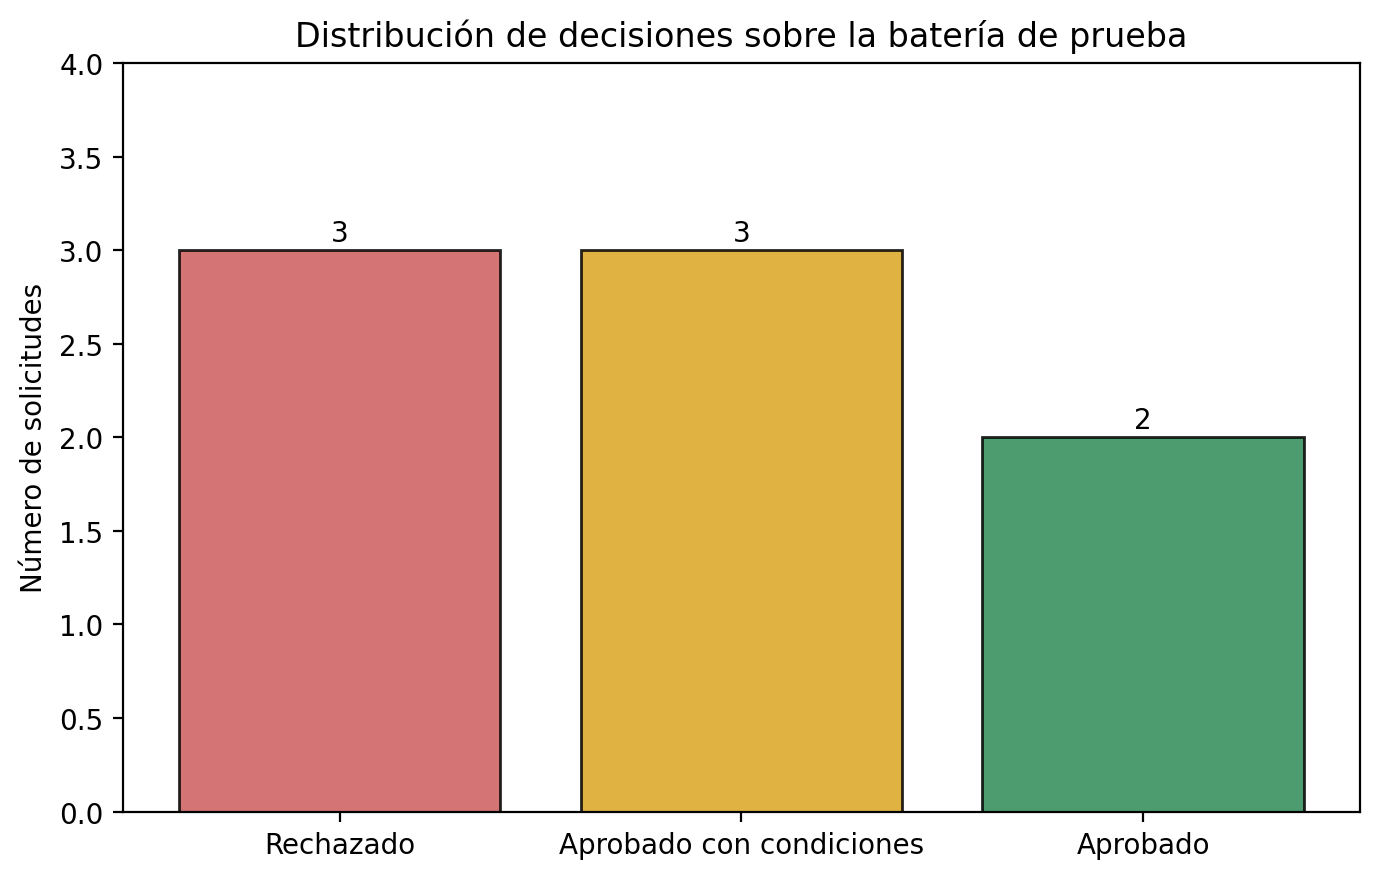

In [6]:
conteo_decisiones = tabla_resultados["Decisión"].value_counts()
colores = {"Aprobado": "seagreen", "Aprobado con condiciones": "goldenrod", "Rechazado": "indianred"}

plt.figure(figsize=(7, 4.5), dpi=200)
barras = plt.bar(
    conteo_decisiones.index,
    conteo_decisiones.values,
    color=[colores[d] for d in conteo_decisiones.index],
    edgecolor="black",
    alpha=0.85,
)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura + 0.05, str(int(altura)), ha="center")
plt.title("Distribución de decisiones sobre la batería de prueba")
plt.ylabel("Número de solicitudes")
plt.ylim(0, max(conteo_decisiones.values) + 1)
plt.tight_layout()
plt.show()

# Conclusiones

Separar explícitamente la base de hechos, la base de conocimiento y el motor de inferencia — en vez de fusionar los tres en una cadena de `if/elif` como en el ejemplo del enunciado — permitió construir un sistema de reglas para evaluación de riesgo crediticio en dos niveles: reglas de categorización (DTI, score, antigüedad, historial) que derivan hechos intermedios, y reglas de decisión que consumen esos hechos para llegar a un veredicto. El **encadenamiento hacia adelante** (motor_inferencia) hace que este diseño en niveles funcione sin necesidad de ordenar manualmente las reglas de categorización entre sí: el motor las dispara en cuanto sus condiciones están satisfechas, en tantas pasadas como haga falta.

La batería de prueba, diseñada para forzar cada una de las cinco rutas de decisión, confirmó que el **orden de las reglas de decisión funciona como mecanismo de resolución de conflictos**: el caso de sobreendeudamiento con baja estabilidad fue rechazado por la regla correspondiente y no por las dos reglas de rechazo automático que se evalúan primero (historial y score), porque ninguna de esas dos condiciones se cumplía para ese solicitante — el sistema no solo llega a la decisión correcta, sino que además, gracias a la regla `explicar`, puede justificar textualmente cuál fue el motivo.

Frente al ejemplo del enunciado, la principal ganancia no es la complejidad del dominio sino la **extensibilidad**: añadir una nueva política de crédito (por ejemplo, un requisito adicional sobre el monto solicitado respecto al ingreso) solo requiere añadir un objeto `Regla` más a la lista, sin tocar el motor ni las reglas existentes — algo que en una cadena de `if/elif` habría exigido reescribir la estructura completa de condicionales. La limitación principal del diseño es la misma que la de cualquier sistema de reglas simple: la lógica es binaria (una condición se cumple o no) y los umbrales, aunque están tomados de referencias reales del sector crediticio, son una simplificación de políticas de originación mucho más matizadas en la práctica.

## Referencias

Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.

Giarratano, J., & Riley, G. (2005). *Expert Systems: Principles and Programming* (4th ed.). Course Technology.

Jackson, P. (1998). *Introduction to Expert Systems* (3rd ed.). Addison-Wesley.

Consumer Financial Protection Bureau. (2013). *Ability-to-Repay and Qualified Mortgage Rule*. [https://www.consumerfinance.gov/rules-policy/final-rules/ability-to-repay-and-qualified-mortgage-standards-under-the-truth-in-lending-act-regulation-z/](https://www.consumerfinance.gov/rules-policy/final-rules/ability-to-repay-and-qualified-mortgage-standards-under-the-truth-in-lending-act-regulation-z/)

Fair Isaac Corporation. (s.f.). *What's in my FICO Scores?* myFICO. [https://www.myfico.com/credit-education/whats-in-your-credit-score](https://www.myfico.com/credit-education/whats-in-your-credit-score)

Hernández Parada, M. S. (2026). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/7%20-%20Razonamiento%20Inteligente/Practica%201.1/Implementar%20un%20sistema%20basado%20en%20reglas%20simples%20usando%20Python%20y%20R.ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/7%20-%20Razonamiento%20Inteligente/Practica%201.1/Implementar%20un%20sistema%20basado%20en%20reglas%20simples%20usando%20Python%20y%20R.ipynb)